<a href="https://colab.research.google.com/github/UmymaM/DeepFake-Detection/blob/main/src/inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import torch
import sys
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
sys.path.append("/content/drive/MyDrive/DeepFake-Detection/src")
from models.dual_branch import DualBranchNet
from data.transforms import get_val_transforms

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
model=DualBranchNet().to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 132MB/s]


In [6]:
checkpoint=torch.load(
    "/content/drive/MyDrive/dual_branch_best.pth",
    map_location=device)

In [7]:
model.load_state_dict(checkpoint)
model.eval()

DualBranchNet(
  (spatial_branch): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNo

In [37]:
def compute_fft(image_tensor):
    gray=0.299*image_tensor[0] + 0.587*image_tensor[1] + 0.114*image_tensor[2]
    fft=torch.fft.fft2(gray)
    fft_shift=torch.fft.fftshift(fft)
    magnitude=torch.log(torch.abs(fft_shift)+1e-8)
    magnitude=(magnitude-magnitude.min())/(magnitude.max()-magnitude.min()+1e-8)
    return magnitude.unsqueeze(0)

In [11]:
transform=get_val_transforms()

In [9]:
img_path="/content/fake_image_1.jpg" #f
image=Image.open(img_path).convert("RGB")

In [18]:
img_path_2="/content/real_image_1.jpg" #r
img_path_3="/content/fake_image_2.avif" #f
image_2=Image.open(img_path_2).convert("RGB")
image_3=Image.open(img_path_3).convert("RGB")

In [34]:
img_path_4="/content/saba_qamar.webp" #r
image_4=Image.open(img_path_4).convert("RGB")
img_path_5="/content/sanam_saeed.webp" #r
image_5=Image.open(img_path_5).convert("RGB")
img_path_6="/content/sajal.jpg" #r
image_6=Image.open(img_path_6).convert("RGB")
img_path_7="/content/sajal_chatgpt.png" #f
image_7=Image.open(img_path_7).convert("RGB")
img_path_8="/content/hania.jpg" #f
image_8=Image.open(img_path_8).convert("RGB")

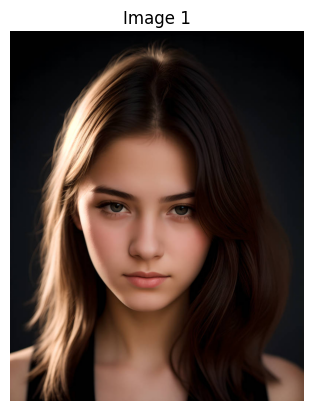

Image 1: MANIPULATED/FAKE (Probability: 1.0000)



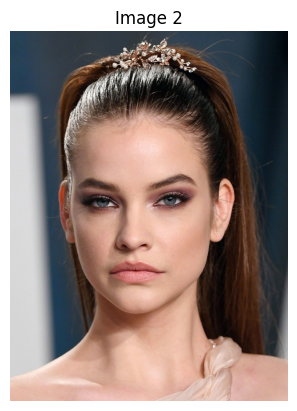

Image 2: MANIPULATED/FAKE (Probability: 1.0000)



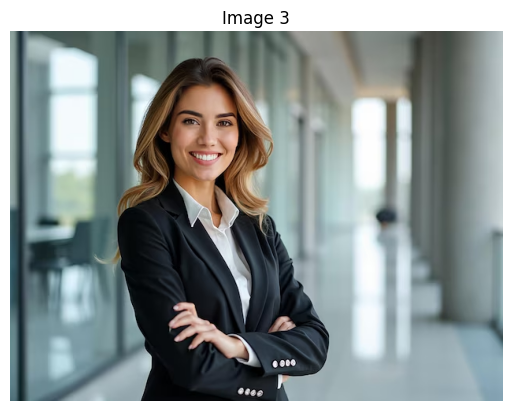

Image 3: MANIPULATED/FAKE (Probability: 0.9712)



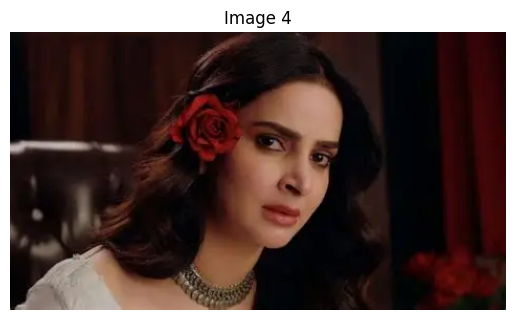

Image 4: REAL (Probability: 0.5282)



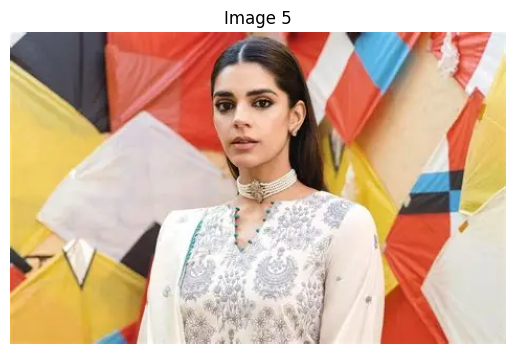

Image 5: REAL (Probability: 0.4239)



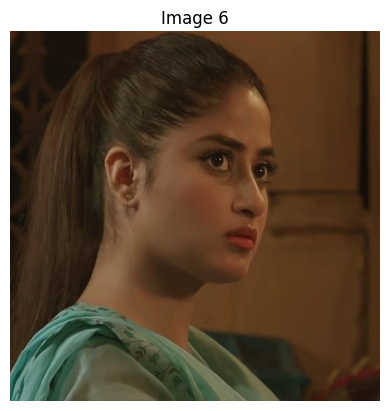

Image 6: REAL (Probability: 0.5964)



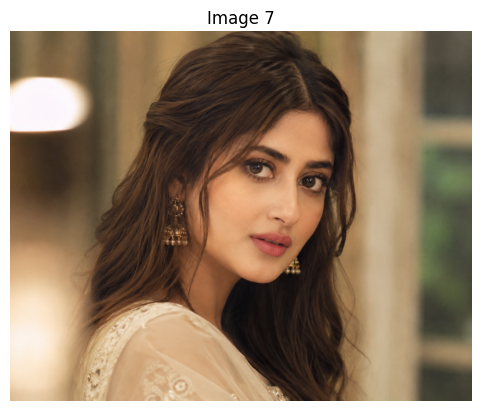

Image 7: MANIPULATED/FAKE (Probability: 0.9107)



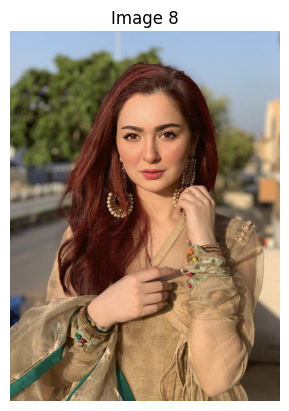

Image 8: MANIPULATED/FAKE (Probability: 1.0000)



In [36]:
images=[image,image_2,image_3,image_4,image_5,image_6,image_7,image_8]

for idx, img in enumerate(images):
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {idx+1}")
    plt.show()
    #preprocessing
    img_tensor=transform(img)
    fft_tensor=compute_fft(img_tensor)
    #moving to gpu
    img_tensor=img_tensor.unsqueeze(0).to(device)
    fft_tensor=fft_tensor.unsqueeze(0).to(device)
    #predicting
    with torch.no_grad():
        output=model(img_tensor,fft_tensor)
        prob=torch.sigmoid(output).item()
    #predictions
    label = "MANIPULATED/FAKE" if prob > 0.60 else "REAL"
    print(f"Image {idx+1}: {label} (Probability: {prob:.4f})\n")